# Task 1 - Data Understanding and Preparation

This notebook follows the KDD process for the first project: data loading, merge validation, quality assessment, exploratory analysis, and feature engineering.


In [58]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

import functions as uf

%load_ext autoreload
%autoreload 2

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="talk")

candidate_dirs = [Path.cwd().parent / "dataset", Path.cwd() / "dataset"]
DATA_DIR = next((path for path in candidate_dirs if (path / "artists.csv").exists() and (path / "tracks.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate the repo-level dataset/ directory.")

print(f"Using data directory: {DATA_DIR.resolve()}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using data directory: /home/simone_grandinetti/ML_first_project/dataset


## Load The Raw Datasets

`artists.csv` is semicolon-separated, while `tracks.csv` is comma-separated and includes quoted multiline lyrics.


In [59]:
df_artist = pd.read_csv(DATA_DIR / "artists.csv", sep=";")
df_track = pd.read_csv(DATA_DIR / "tracks.csv", sep=",")

print(f"Artists shape: {df_artist.shape}")
print(f"Tracks shape: {df_track.shape}")

display(df_artist.head())
display(df_track.head(2))


Artists shape: (104, 14)
Tracks shape: (11166, 45)


,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
0,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,ART53496045,achille lauro,M,1990-07-11,Verona,Italia,cantautore e rapper italiano (1990-),2012-01-01,NaN,Verona,Veneto,Italia,45.442498,10.985738
2,ART18853907,alfa,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ART64265460,anna pepe,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ART75741740,articolo 31,M,NaN,NaN,NaN,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN


,id,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,swear_IT,swear_EN,swear_IT_words,swear_EN_words,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_name,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity
0,TR934808,ART04205421,Rosa Chemical,​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè),​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,196033.0,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...","['bitch', 'fuck', 'porno', 'pussy']",2021.0,4.0,2.0,102.0,911.0,8.931373,4.170455,0.575284,8.133929,135.32,0.1858,2895.7767,1.4499,0.1786,0.1046,0.8202,25.7148,2311.1779,17.8675,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",False
1,TR760029,ART04205421,Rosa Chemical,POLKA by Rosa Chemical (Ft. Thelonious B.),POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,164450.0,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...","['escort', 'negro', 'sex', 'sexy', 'shit']",2020.0,3.0,6.0,56.0,675.0,12.053571,4.280851,0.648936,12.500000,129.37,0.2071,3378.4605,1.3533,0.2020,0.1175,0.6739,29.1089,1892.1924,21.4595,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",False


## Merge Validation And Dataset Overview

We merge artist-level and song-level data using the artist identifier, then verify coverage and summarize the variables by semantic role.


In [60]:
df = pd.merge(
    df_artist,
    df_track,
    left_on="id_author",
    right_on="id_artist",
    validate="one_to_many",
).rename(columns={"id": "id_song"})

merge_overview = pd.DataFrame(
    {
        "metric": [
            "artist_rows",
            "track_rows",
            "merged_rows",
            "unique_artists_in_artists",
            "unique_artists_in_tracks",
            "unique_artists_after_merge",
            "unique_song_ids_after_merge",
            "artist_features",
            "track_features",
            "merged_features",
            "merge_coverage_pct",
        ],
        "value": [
            len(df_artist),
            len(df_track),
            len(df),
            df_artist["id_author"].nunique(),
            df_track["id_artist"].nunique(),
            df["id_author"].nunique(),
            df["id_song"].nunique(),
            df_artist.shape[1],
            df_track.shape[1],
            df.shape[1],
            round(100 * len(df) / len(df_track), 2),
        ],
    }
)

display(merge_overview)
print(f"Expected working dataset: {len(df)} rows over {df['id_author'].nunique()} artists.")


,metric,value
0,artist_rows,104.0
1,track_rows,11166.0
2,merged_rows,11166.0
3,unique_artists_in_artists,104.0
4,unique_artists_in_tracks,104.0
5,unique_artists_after_merge,104.0
6,unique_song_ids_after_merge,11093.0
7,artist_features,14.0
8,track_features,45.0
9,merged_features,59.0


Expected working dataset: 11166 rows over 104 artists.


In [61]:
feature_group_table = uf.feature_group_table(df).sort_values(["level", "group", "feature"]).reset_index(drop=True)
feature_group_summary = (
    feature_group_table.groupby(["level", "group"])
    .size()
    .rename("n_features")
    .reset_index()
)
engineered_docs = uf.engineered_feature_table()

display(feature_group_summary)
display(feature_group_table)
display(engineered_docs)


,level,group,n_features
0,artist,artist_level,7
1,artist,geographic,7
2,song,audio,10
3,song,song_level,25
4,song,textual,10


,feature,group,level
0,active_end,artist_level,artist
1,active_start,artist_level,artist
2,birth_date,artist_level,artist
3,description,artist_level,artist
4,gender,artist_level,artist
5,id_author,artist_level,artist
6,name,artist_level,artist
7,birth_place,geographic,artist
8,country,geographic,artist
9,latitude,geographic,artist


,feature,family,role,description
0,swear_IT,textual,provided feature,Count of Italian swear words detected in the l...
1,swear_EN,textual,provided feature,Count of English swear words detected in the l...
2,swear_IT_words,textual,provided feature,List of matched Italian swear words found in t...
3,swear_EN_words,textual,provided feature,List of matched English swear words found in t...
4,n_sentences,textual,provided feature,Number of detected sentences in the lyrics.
5,n_tokens,textual,provided feature,Number of detected tokens/words in the lyrics.
6,tokens_per_sent,textual,provided feature,Average number of tokens per sentence.
7,char_per_tok,textual,provided feature,Average number of characters per token.
8,lexical_density,textual,provided feature,Ratio of lexical words over all tokens.
9,avg_token_per_clause,textual,provided feature,Average number of tokens per clause.


## Redundant Text Fields

Before deeper analysis, we check the overlap between duplicated textual columns and keep the richer representation when redundancy is high.


In [62]:
print(f"NaN in 'album': {df['album'].isna().sum()}")
print(f"NaN in 'album_name': {df['album_name'].isna().sum()}")
album_comparison, album_score = uf.compare_text_columns(df, "album", "album_name")

title_comparison, title_score = uf.compare_text_columns(df, "title", "full_title")

redundancy_summary = pd.DataFrame(
    [
        {
            "pair": "album vs album_name",
            "rows_evaluated": len(album_comparison),
            "avg_similarity": round(album_score, 2),
            "decision": "drop album",
            "motivation": "album_name has far fewer missing values",
        },
        {
            "pair": "title vs full_title",
            "rows_evaluated": len(title_comparison),
            "avg_similarity": round(title_score, 2),
            "decision": "drop title",
            "motivation": "full_title preserves featured-artist context",
        },
    ]
)

display(redundancy_summary)
display(album_comparison.nsmallest(10, "similarity_score"))
display(title_comparison.nsmallest(10, "similarity_score"))

df = df.drop(columns=["album", "title"])


NaN in 'album': 1514
NaN in 'album_name': 78


,pair,rows_evaluated,avg_similarity,decision,motivation
0,album vs album_name,9579,79.88,drop album,album_name has far fewer missing values
1,title vs full_title,11166,98.73,drop title,full_title preserves featured-artist context


,album,album_name,similarity_score
688,Lezioni di Volo,6AM,0.0
694,Lezioni di Volo,12,0.0
910,Seven: The Street Prequel,KG,0.0
1140,Ancora3cmdiossigeno,70 x 70,0.0
1432,Zappa,?!,0.0
1434,Ricomincio da Capa,?!,0.0
1438,Ricomincio da Capa,?!,0.0
1463,Zappa,?!,0.0
1470,Zappa,?!,0.0
1957,1998,Mal di te,0.0


,title,full_title,similarity_score
100,Ammo’,Ammo' by Achille Lauro (Ft. Clementino & Rocco...,14.035088
550,I’&I’,I'&I' by Babaman (Ft. Stevie Deville),14.285714
8421,“El Padre”,"""El Padre"" by Noyz Narcos & Fritz Da Cat",20.000000
851,Com’era,Com'era by Bassi Maestro & DJ Shocca (Ft. Anag...,20.689655
6536,Alfredo’s,"Alfredo's by MadMan (Ft. Ill Nacho, Lil' Pin, ...",21.621622
4047,L’inutile,L'inutile by Frankie hi-nrg mc (Ft. Paola Cort...,25.806452
6802,L’Albatro,L'Albatro by Marracash (Ft. Dargen D'Amico & R...,25.806452
4794,L’Amore,L'Amore by Ghemon (Ft. Frank Siciliano),26.086957
339,M’ama,M'ama by Alfa (Ft. Ytema),26.666667
9427,L’ODIO,L'ODIO by Salmo & Noyz Narcos,28.571429


## Cleaning, Typing, And Derived Dates

We standardize missing values, coerce numeric/date columns, validate boolean fields, and derive a cleaned release year for later analysis.


In [63]:
df = df.replace(r"^\s*$", np.nan, regex=True)

numeric_columns = [
    "stats_pageviews",
    "swear_IT",
    "swear_EN",
    "year",
    "month",
    "day",
    "n_sentences",
    "n_tokens",
    "tokens_per_sent",
    "char_per_tok",
    "lexical_density",
    "avg_token_per_clause",
    "bpm",
    "centroid",
    "rolloff",
    "flux",
    "rms",
    "zcr",
    "flatness",
    "spectral_complexity",
    "pitch",
    "loudness",
    "disc_number",
    "track_number",
    "duration_ms",
    "popularity",
    "modified_popularity",
    "latitude",
    "longitude",
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

for column in ["birth_date", "active_start", "active_end", "album_release_date"]:
    df[column] = pd.to_datetime(df[column], errors="coerce")

explicit_map = {True: True, False: False, "True": True, "False": False}
df["explicit"] = df["explicit"].map(explicit_map)
df["explicit_numeric"] = df["explicit"].astype("float")

current_year = pd.Timestamp.today().year
plausible_track_year = df["year"].between(1900, current_year + 1)
plausible_album_year = df["album_release_date"].dt.year.between(1900, current_year + 1)

df["track_release_date"] = pd.to_datetime(
    {
        "year": df["year"],
        "month": df["month"],
        "day": df["day"],
    },
    errors="coerce",
)

df["release_year"] = df["year"].where(plausible_track_year)
df["release_year"] = df["release_year"].fillna(df["album_release_date"].dt.year.where(plausible_album_year))

display(df[["birth_date", "active_start", "active_end", "album_release_date", "track_release_date", "release_year"]].head())


,birth_date,active_start,active_end,album_release_date,track_release_date,release_year
0,NaT,1991-01-01,NaT,1993-06-12,NaT,1993.0
1,NaT,1991-01-01,NaT,1993-06-12,1993-06-12,1993.0
2,NaT,1991-01-01,NaT,1993-06-12,1993-06-12,1993.0
3,NaT,1991-01-01,NaT,NaT,NaT,1998.0
4,NaT,1991-01-01,NaT,2014-03-25,2014-03-25,2014.0


## Missing Values

The table below summarizes missingness by feature and by semantic group so that later modeling choices can separate structural missingness from optional metadata.


,feature,missing_count,missing_pct,group,level
0,active_end,11166,100.00,artist_level,artist
1,featured_artists,7649,68.50,song_level,song
2,stats_pageviews,6524,58.43,song_level,song
3,active_start,4601,41.21,artist_level,artist
4,region,3142,28.14,geographic,artist
5,province,2699,24.17,geographic,artist
6,country,2699,24.17,geographic,artist
7,nationality,2609,23.37,geographic,artist
8,birth_date,2578,23.09,artist_level,artist
9,birth_place,2578,23.09,geographic,artist


,level,group,avg_missing_count,avg_missing_pct
0,artist,artist_level,2783.285714,24.927143
1,artist,geographic,2697.571429,24.160000
4,song,song_level,792.652174,7.099565
3,song,derived,489.666667,4.386667
2,song,audio,64.000000,0.570000
5,song,textual,45.600000,0.408000


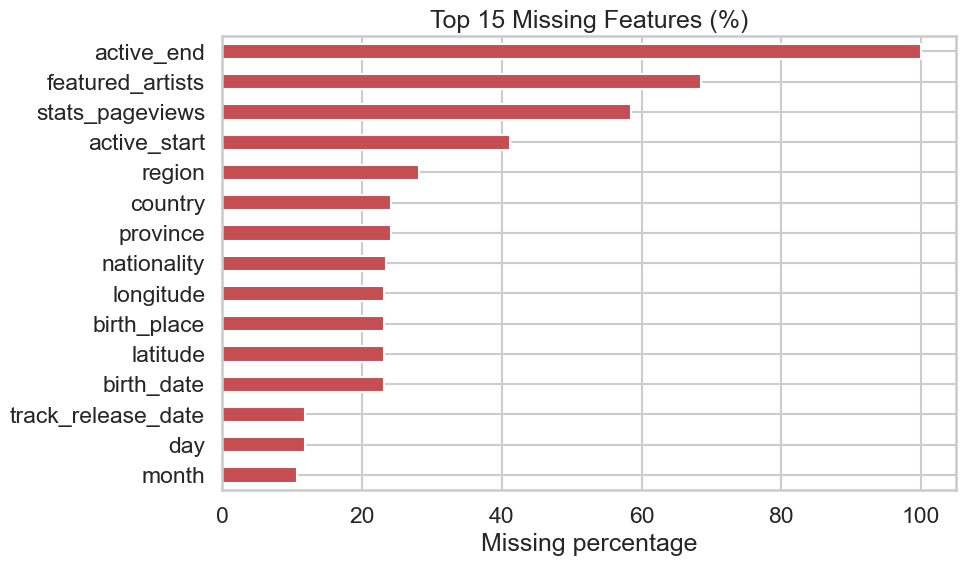

In [64]:
feature_lookup = uf.feature_group_table(df).drop_duplicates(subset=["feature"]).set_index("feature")
missing_summary = pd.DataFrame(
    {
        "feature": df.columns,
        "missing_count": df.isna().sum().values,
    }
)
missing_summary["missing_pct"] = (100 * missing_summary["missing_count"] / len(df)).round(2)
missing_summary = missing_summary.join(feature_lookup[["group", "level"]], on="feature")
missing_summary = missing_summary.fillna({"group": "derived", "level": "song"})
missing_summary = missing_summary.sort_values(["missing_pct", "missing_count"], ascending=False).reset_index(drop=True)

group_missing = (
    missing_summary.groupby(["level", "group"])[["missing_count", "missing_pct"]]
    .mean()
    .rename(columns={"missing_count": "avg_missing_count", "missing_pct": "avg_missing_pct"})
    .reset_index()
    .sort_values("avg_missing_pct", ascending=False)
)

display(missing_summary)
display(group_missing)

fig, ax = plt.subplots(figsize=(10, 6))
missing_summary.head(15).sort_values("missing_pct").plot.barh(
    x="feature",
    y="missing_pct",
    ax=ax,
    legend=False,
    color="#c44e52",
)
ax.set_title("Top 15 Missing Features (%)")
ax.set_xlabel("Missing percentage")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Duplicates And Inconsistent Values

We inspect duplicate identifiers, repeated merged rows, repeated artist-title combinations, and potentially inconsistent categorical labels.


In [65]:
duplicate_song_id_mask = df["id_song"].duplicated(keep=False)
duplicate_row_mask = df.duplicated(keep=False)
duplicate_artist_title_mask = df.duplicated(subset=["name", "full_title"], keep=False)

normalized_name_artist = df["name_artist"].map(uf.normalize_text)
normalized_name = df["name"].map(uf.normalize_text)
artist_name_mismatch_mask = normalized_name_artist != normalized_name

duplicates_summary = pd.DataFrame(
    [
        {"check": "duplicated_song_ids", "count": int(duplicate_song_id_mask.sum())},
        {"check": "fully_duplicated_rows", "count": int(duplicate_row_mask.sum())},
        {"check": "duplicated_artist_full_title_pairs", "count": int(duplicate_artist_title_mask.sum())},
        {"check": "artist_name_mismatches", "count": int(artist_name_mismatch_mask.sum())},
    ]
)

display(duplicates_summary)
display(
    df.loc[duplicate_song_id_mask, ["id_song", "name", "full_title", "album_name", "release_year"]]
    .sort_values(["id_song", "release_year"])
    .head(20)
)
display(
    df.loc[artist_name_mismatch_mask, ["name", "name_artist", "full_title"]]
    .drop_duplicates()
    .head(20)
)


,check,count
0,duplicated_song_ids,144
1,fully_duplicated_rows,0
2,duplicated_artist_full_title_pairs,4
3,artist_name_mismatches,872


,id_song,name,full_title,album_name,release_year
8414,TR108862,noyz narcos,SPINE by Noyz Narcos (Ft. Coez),VIRUS,1932.0
848,TR108862,bassi maestro,Sushi Bar by Bassi Maestro,Sushi - EP,2007.0
4771,TR135764,ghemon,Nessuno vale quanto te by Ghemon,ORCHIdee,2014.0
2992,TR135764,emis killa,Giovani eroi by Emis Killa (Ft. Not Good),"Keta Music, Vol. 3",2021.0
2013,TR190585,coez,Nei treni la notte by Coez (Ft. Frah Quintale),From The Rooftop 2,2022.0
8617,TR190585,piotta,Serpico by Piotta (Ft. Tiromancino),'na notte infame,2024.0
5912,TR192351,jake la furia,Musica Commerciale by Jake La Furia,Musica Commerciale,2013.0
1917,TR192351,club dogo,Tornerò Da Re - Redrum Version by Club Dogo,Vile Denaro 10th Anniversary,2017.0
5815,TR205970,jack the smoker,24.7 by Jack The Smoker (Ft. Bassi Maestro & Guè),V.Ita,1910.0
8819,TR205970,rancore,Sigla Catteland by Rancore & DJ Myke,Musica per bambini,2013.0


,name,name_artist,full_title
344,anna pepe,ANNA,Bando by ANNA
345,anna pepe,ANNA,TT LE GIRLZ by ANNA (Ft. Niky Savage)
346,anna pepe,ANNA,I LOVE IT by ANNA (Ft. Artie 5ive)
347,anna pepe,ANNA,ABC by ANNA (Ft. thasup & Tony Boy)
348,anna pepe,ANNA,30°C by ANNA
349,anna pepe,ANNA,BBE by ANNA (Ft. Lazza)
350,anna pepe,ANNA,BIKINI by ANNA (Ft. Guè)
351,anna pepe,ANNA,UNA TIPA COME ME by ANNA
352,anna pepe,ANNA,HELLO KITTY by ANNA (Ft. Sillyelly)
353,anna pepe,ANNA,VIENI DALLA BADDIE (interlude) by ANNA


In [66]:
for column in ["language", "album_type", "explicit", "region", "country", "nationality"]:
    print(f"\nValue counts for {column}:")
    display(df[column].value_counts(dropna=False).rename("count").to_frame().head(15))



Value counts for language:


,count
language,
it,9352
en,843
pl,588
NaN,105
es,63
co,48
pt,45
da,18
cs,14



Value counts for album_type:


,count
album_type,
album,9353
single,1544
compilation,191
NaN,78



Value counts for explicit:


...

,count
region,
NaN,3142
Lombardia,2662
Campania,1296
Lazio,1154
Veneto,693
Piemonte,599
Sardegna,526
Puglia,350
Liguria,315



Value counts for country:


,count
country,
Italia,8467
NaN,2699



Value counts for nationality:


,count
nationality,
Italia,8517
NaN,2609
Argentina,40


## Incorrect Dates And Extreme Values (OOD)

We flag impossible dates, implausible years, and suspicious numeric values using both domain rules and robust IQR-based summaries.


In [67]:
current_year = pd.Timestamp.today().year
partial_track_date_mask = df[["year", "month", "day"]].notna().any(axis=1)

invalid_date_summary = pd.DataFrame(
    [
        {"check": "birth_date_in_future", "count": int((df["birth_date"] > pd.Timestamp.today()).sum())},
        {"check": "active_start_in_future", "count": int((df["active_start"] > pd.Timestamp.today()).sum())},
        {"check": "active_end_before_active_start", "count": int((df["active_end"] < df["active_start"]).sum())},
        {"check": "album_release_date_in_future", "count": int((df["album_release_date"] > pd.Timestamp.today()).sum())},
        {"check": "track_year_outside_1900_to_current+1", "count": int((df["year"].notna() & ~df["year"].between(1900, current_year + 1)).sum())},
        {"check": "invalid_track_release_date_from_parts", "count": int((partial_track_date_mask & df["track_release_date"].isna()).sum())},
        {"check": "release_year_missing_after_cleaning", "count": int(df["release_year"].isna().sum())},
    ]
)

domain_rules = {
    "popularity": lambda s: (s < 0) | (s > 100),
    "modified_popularity": lambda s: s < 0,
    "stats_pageviews": lambda s: s < 0,
    "bpm": lambda s: (s <= 0) | (s > 300),
    "duration_ms": lambda s: (s <= 0) | (s > 900000),
    "tokens_per_sent": lambda s: s <= 0,
    "avg_token_per_clause": lambda s: s < 0,
    "lexical_density": lambda s: (s < 0) | (s > 1),
    "year": lambda s: (s < 1900) | (s > current_year + 1),
}

outlier_summary = uf.summarize_outliers(
    df,
    columns=[
        "popularity",
        "modified_popularity",
        "stats_pageviews",
        "bpm",
        "duration_ms",
        "tokens_per_sent",
        "avg_token_per_clause",
        "lexical_density",
        "year",
    ],
    domain_rules=domain_rules,
)

suspicious_counts = pd.DataFrame(
    [
        {"check": "year_equals_2100", "count": int((df["year"] == 2100).sum())},
        {"check": "negative_popularity", "count": int((df["popularity"] < 0).sum())},
        {"check": "popularity_above_100", "count": int((df["popularity"] > 100).sum())},
        {"check": "bpm_above_300", "count": int((df["bpm"] > 300).sum())},
        {"check": "duration_above_15_minutes", "count": int((df["duration_ms"] > 900000).sum())},
    ]
)

display(invalid_date_summary)
display(outlier_summary)
display(suspicious_counts)


,check,count
0,birth_date_in_future,0
1,active_start_in_future,0
2,active_end_before_active_start,0
3,album_release_date_in_future,0
4,track_year_outside_1900_to_current+1,1036
5,invalid_track_release_date_from_parts,887
6,release_year_missing_after_cleaning,66


,feature,valid_count,q1,q3,iqr_lower,iqr_upper,iqr_outliers,iqr_outlier_pct,domain_outliers,domain_outlier_pct,min,max
0,popularity,11137,16.000000,47.000000,-30.500000,93.500000,58,0.52,49,0.44,-954.00,993842.00
1,modified_popularity,11166,0.000000,0.000000,0.000000,0.000000,78,0.70,0,0.00,0.00,1.00
2,stats_pageviews,4642,9642.250000,42011.750000,-38912.000000,90566.000000,418,9.00,0,0.00,5006.00,1971207.00
3,bpm,11102,91.910000,134.650000,27.800000,198.760000,1,0.01,1,0.01,59.97,738.27
4,duration_ms,11088,170131.000000,227184.000000,84551.500000,312763.500000,495,4.46,16,0.14,11426.00,3753057.00
5,tokens_per_sent,11090,7.333333,9.431527,4.186042,12.578818,399,3.60,0,0.00,1.50,400.00
6,avg_token_per_clause,11090,5.859020,8.090909,2.511185,11.438743,731,6.59,0,0.00,0.00,660.00
7,lexical_density,11090,0.482353,0.542450,0.392207,0.632597,520,4.69,0,0.00,0.00,1.00
8,year,10728,2009.000000,2021.000000,1991.000000,2039.000000,2153,20.07,1036,9.66,1900.00,2100.00


,check,count
0,year_equals_2100,14
1,negative_popularity,28
2,popularity_above_100,21
3,bpm_above_300,1
4,duration_above_15_minutes,16


## Feature Engineering

We build a single, consolidated feature engineering step that includes the original project features plus additional clustering-oriented features for Task 3.


In [74]:
# Original project features
df["swear_total"] = df[["swear_IT", "swear_EN"]].fillna(0).sum(axis=1)
df["swear_density_total"] = uf.safe_divide(df["swear_total"], df["n_tokens"])
df["artist_macroarea"] = df["region"].apply(uf.map_region_to_macroarea)
df["sentence_complexity_index"] = uf.build_weighted_zscore(
    df,
    columns=["tokens_per_sent", "avg_token_per_clause", "lexical_density", "char_per_tok"],
    weights=[1, 1, 1, 1],
    min_non_missing=3,
)

# Additional clustering-oriented features
artist_song_count = df.groupby("id_author").size()
df["artist_song_count"] = df["id_author"].map(artist_song_count)

df["audio_signature_score"] = uf.audio_signature_score(df)

current_year = pd.Timestamp.today().year
df["release_recency_years"] = (current_year - df["release_year"]).clip(lower=0)

df["engagement_ratio"] = uf.safe_divide(df["popularity"], df["stats_pageviews"] + 1)

df["explicit_content_intensity"] = uf.build_weighted_zscore(
    df,
    columns=["explicit_numeric", "swear_density_total"],
    weights=[1, 1],
    min_non_missing=1,
)

df["artist_consistency_score"] = uf.artist_consistency_score(df, artist_col="id_author")
df["lyric_audio_balance"] = uf.safe_divide(df["sentence_complexity_index"], df["audio_signature_score"])
df["artist_geographic_diversity"] = uf.artist_geographic_diversity(
    df,
    artist_col="id_author",
    geo_col="region",
)

engineered_additions = pd.DataFrame(
    [
        {
            "feature": "swear_density_total",
            "formula": "(swear_IT + swear_EN) / n_tokens",
            "motivation": "Compare profanity across songs with different lyric lengths.",
        },
        {
            "feature": "artist_macroarea",
            "formula": "region -> {North, Center, South, Islands, Missing}",
            "motivation": "Stabilize the regional comparison by reducing sparsity.",
        },
        {
            "feature": "sentence_complexity_index",
            "formula": "mean z-score of tokens_per_sent, avg_token_per_clause, lexical_density, char_per_tok",
            "motivation": "Capture a broader notion of textual complexity than a single proxy.",
        },
        {
            "feature": "artist_song_count",
            "formula": "count of songs per artist",
            "motivation": "Identifies prolific vs. one-hit artists for segmentation.",
        },
        {
            "feature": "audio_signature_score",
            "formula": "mean z-score of centroid, rolloff, flux, flatness, loudness, pitch, rms, zcr",
            "motivation": "Aggregates audio tonal profile into a single comparable dimension.",
        },
        {
            "feature": "release_recency_years",
            "formula": "current_year - release_year (clipped at 0)",
            "motivation": "Captures freshness vs. catalog depth; temporal signal for clustering.",
        },
        {
            "feature": "engagement_ratio",
            "formula": "popularity / (stats_pageviews + 1)",
            "motivation": "Measures popularity efficiency relative to traffic.",
        },
        {
            "feature": "explicit_content_intensity",
            "formula": "mean z-score of explicit_numeric and swear_density_total",
            "motivation": "Combines explicit rating and lyric profanity into one signal.",
        },
        {
            "feature": "artist_consistency_score",
            "formula": "mean variance of popularity, duration_ms, swear_density_total across artist songs",
            "motivation": "Lower values indicate more consistent artist behavior.",
        },
        {
            "feature": "lyric_audio_balance",
            "formula": "sentence_complexity_index / audio_signature_score",
            "motivation": "Contrasts lyric complexity with audio profile.",
        },
        {
            "feature": "artist_geographic_diversity",
            "formula": "1 - (artist_count_in_region / artist_count_in_dominant_region)",
            "motivation": "Measures how much an artist origin deviates from the most represented region.",
        },
    ]
)

display(engineered_additions)

feature_snapshot = [
    "swear_total",
    "swear_density_total",
    "artist_macroarea",
    "sentence_complexity_index",
    "artist_song_count",
    "audio_signature_score",
    "release_recency_years",
    "engagement_ratio",
    "explicit_content_intensity",
    "artist_consistency_score",
    "lyric_audio_balance",
    "artist_geographic_diversity",
]

display(df[feature_snapshot].describe(include="all").T)
display(df["artist_macroarea"].value_counts(dropna=False).rename("song_count").to_frame())
display(df[feature_snapshot].isna().sum().rename("missing_count").to_frame())


,feature,formula,motivation
0,swear_density_total,(swear_IT + swear_EN) / n_tokens,Compare profanity across songs with different ...
1,artist_macroarea,"region -> {North, Center, South, Islands, Miss...",Stabilize the regional comparison by reducing ...
2,sentence_complexity_index,"mean z-score of tokens_per_sent, avg_token_per...",Capture a broader notion of textual complexity...
3,artist_song_count,count of songs per artist,Identifies prolific vs. one-hit artists for se...
4,audio_signature_score,"mean z-score of centroid, rolloff, flux, flatn...",Aggregates audio tonal profile into a single c...
5,release_recency_years,current_year - release_year (clipped at 0),Captures freshness vs. catalog depth; temporal...
6,engagement_ratio,popularity / (stats_pageviews + 1),Measures popularity efficiency relative to tra...
7,explicit_content_intensity,mean z-score of explicit_numeric and swear_den...,Combines explicit rating and lyric profanity i...
8,artist_consistency_score,"mean variance of popularity, duration_ms, swea...",Lower values indicate more consistent artist b...
9,lyric_audio_balance,sentence_complexity_index / audio_signature_score,Contrasts lyric complexity with audio profile.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
swear_total,11166.0,NaN,NaN,NaN,3.054182,4.714417,0.0,0.0,2.0,4.0,72.0
swear_density_total,11090.0,NaN,NaN,NaN,0.006016,0.009176,0.0,0.0,0.003273,0.008174,0.2
artist_macroarea,11166,5,North,4368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentence_complexity_index,11090.0,NaN,NaN,NaN,-0.0,0.532062,-3.506259,-0.224963,-0.051379,0.135836,16.22487
artist_song_count,11166.0,NaN,NaN,NaN,158.384202,82.80439,2.0,99.0,148.0,185.0,353.0
audio_signature_score,11102.0,NaN,NaN,NaN,-0.0,0.510778,-3.91608,-0.283413,0.04222,0.334686,2.164396
release_recency_years,11100.0,NaN,NaN,NaN,18.700901,25.81495,1.0,6.0,10.0,18.0,126.0
engagement_ratio,4641.0,NaN,NaN,NaN,0.00305,0.028753,0.0,0.000988,0.001968,0.003602,1.955443
explicit_content_intensity,11093.0,NaN,NaN,NaN,-0.000081,0.762515,-1.015451,-0.727623,0.164587,0.450641,11.063271
artist_consistency_score,11166.0,NaN,NaN,NaN,3030942209.41558,9394856753.676865,73153301.11114,589175818.169262,873584900.459363,1499053500.88486,84891599015.066666


,song_count
artist_macroarea,
North,4368
Missing,3142
South,1715
Center,1233
Islands,708


,missing_count
swear_total,0
swear_density_total,76
artist_macroarea,0
sentence_complexity_index,76
artist_song_count,0
audio_signature_score,64
release_recency_years,66
engagement_ratio,6525
explicit_content_intensity,73
artist_consistency_score,0


## Distribution Analysis

We inspect the main project variables with histograms, boxplots, and violin plots. For heavily skewed variables we also inspect a `log1p` transformed view.


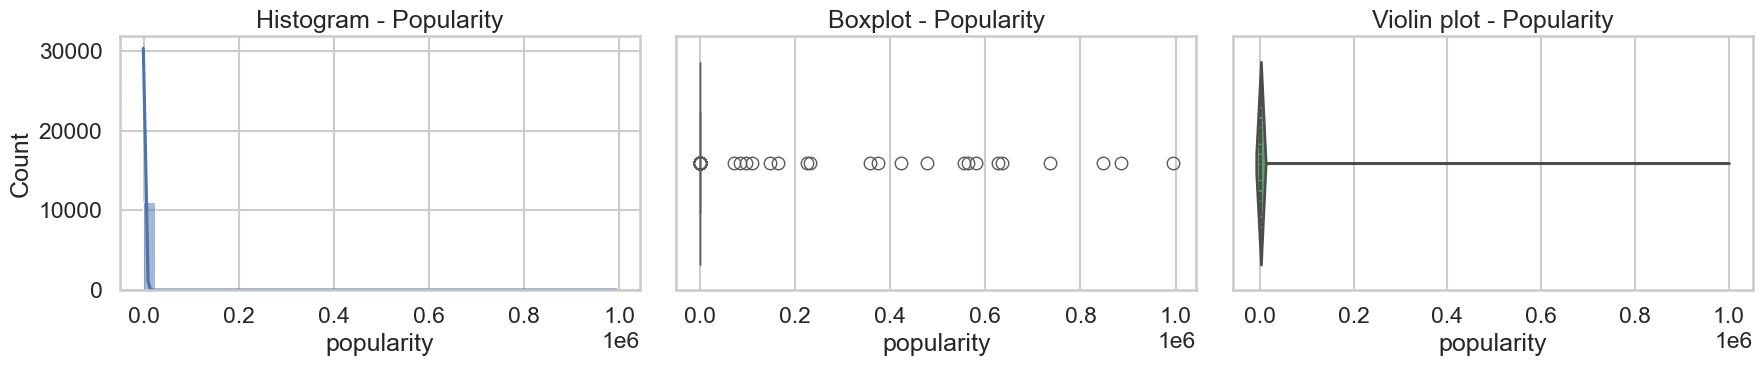

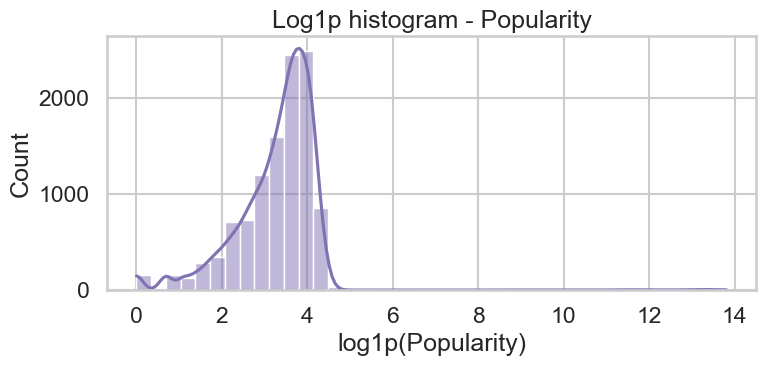

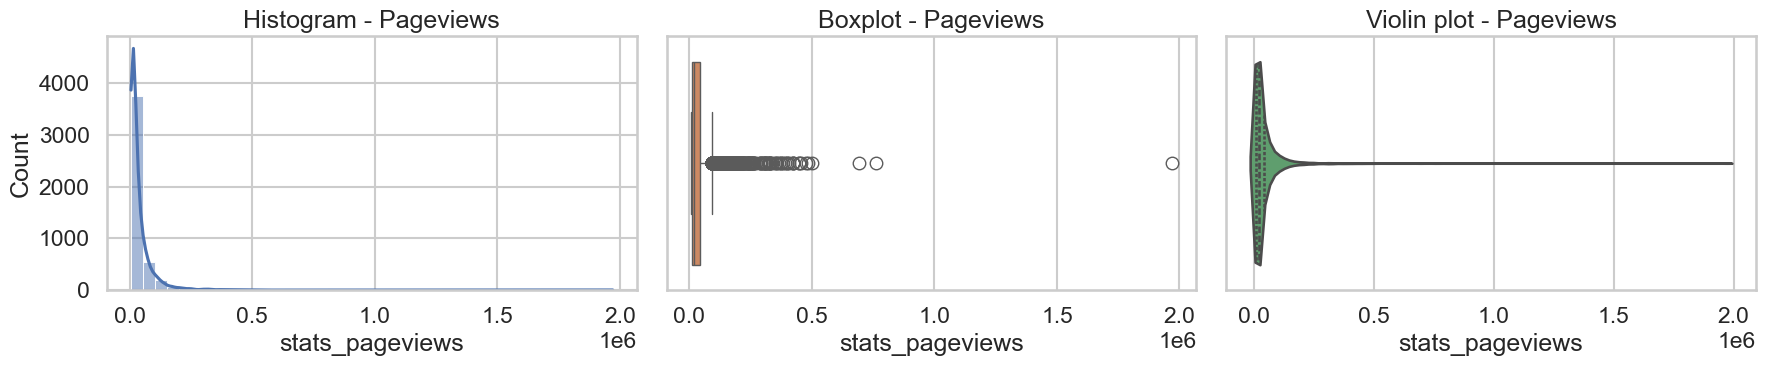

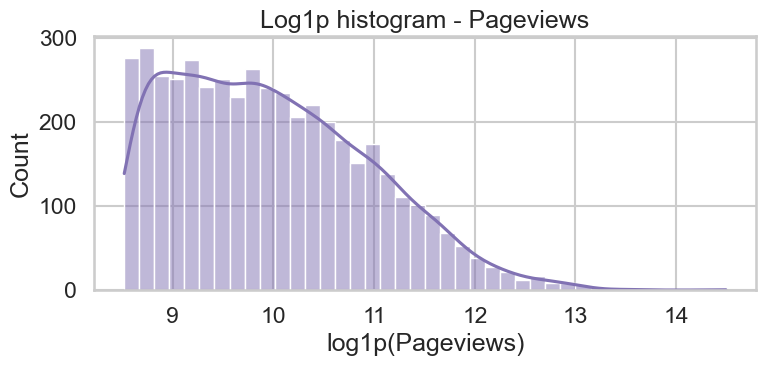

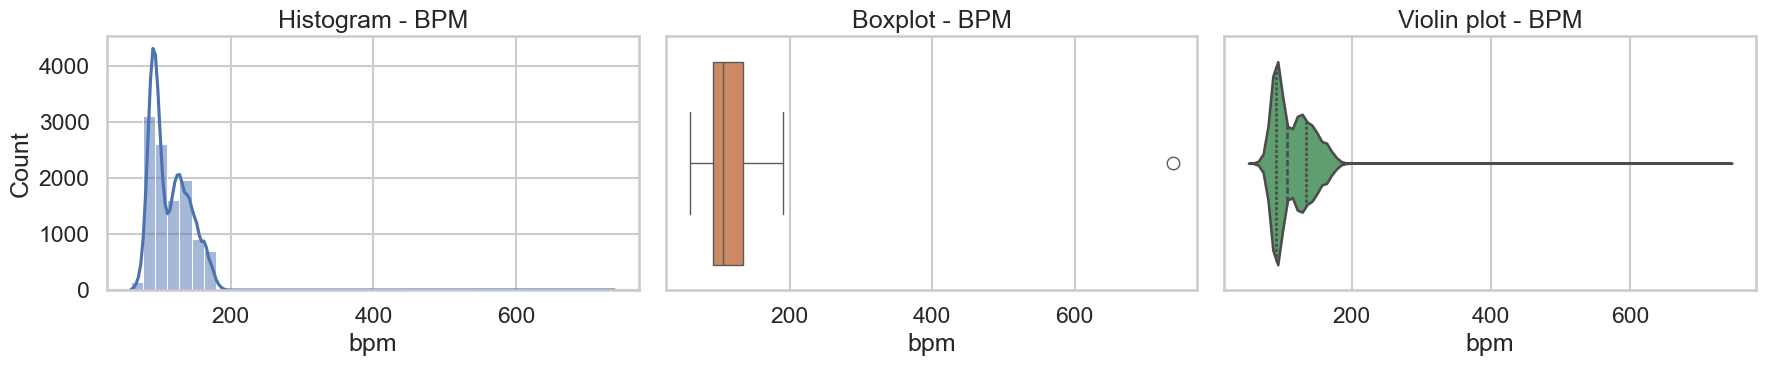

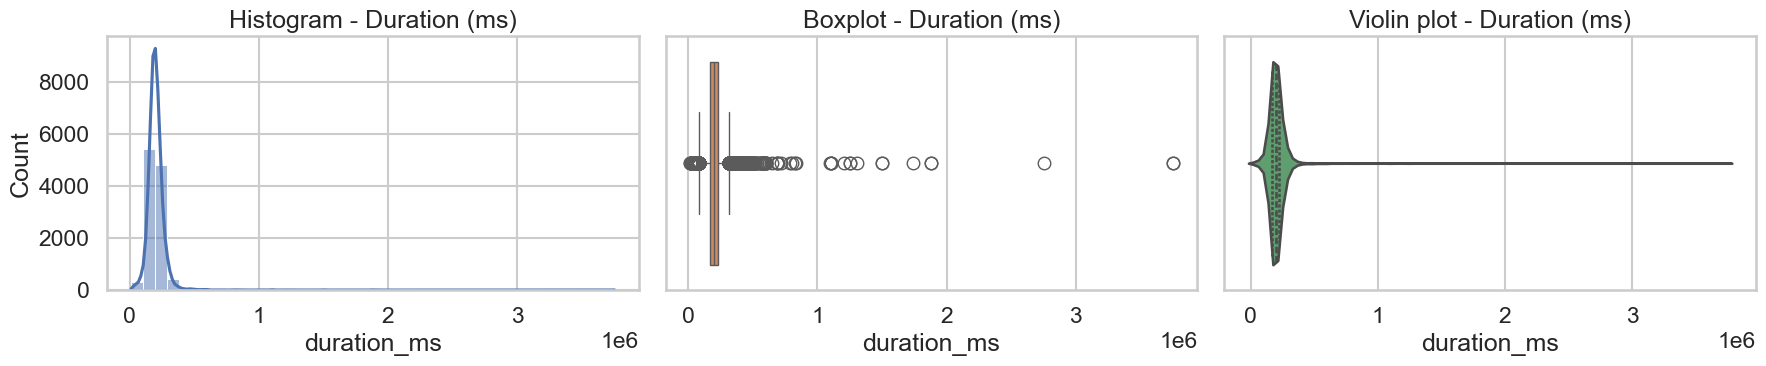

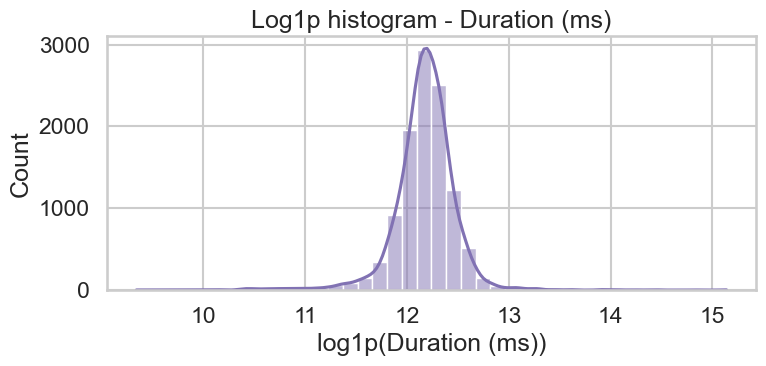

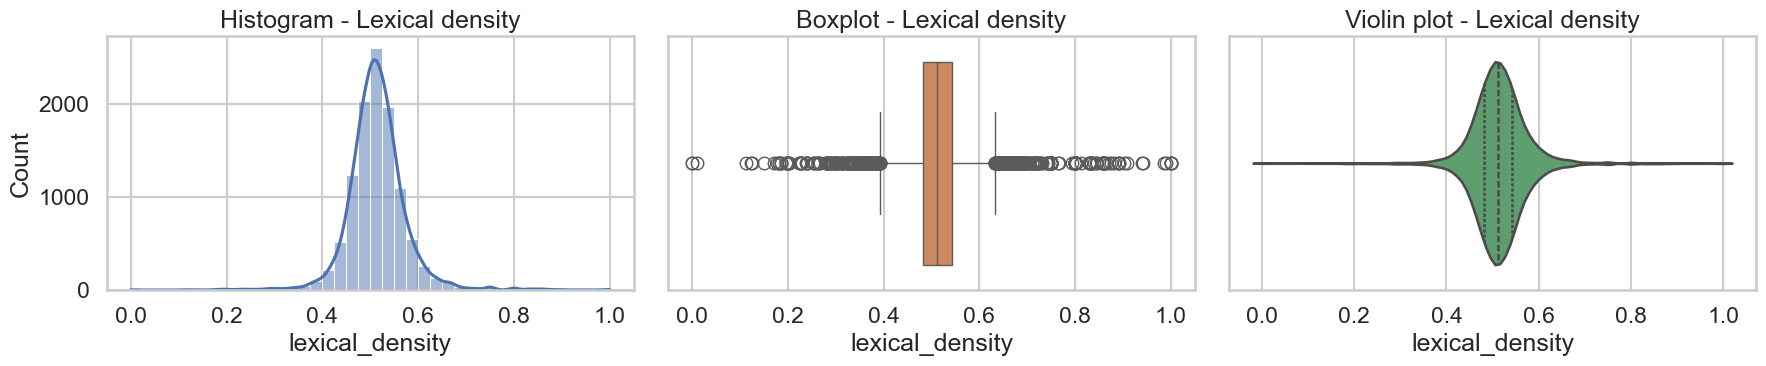

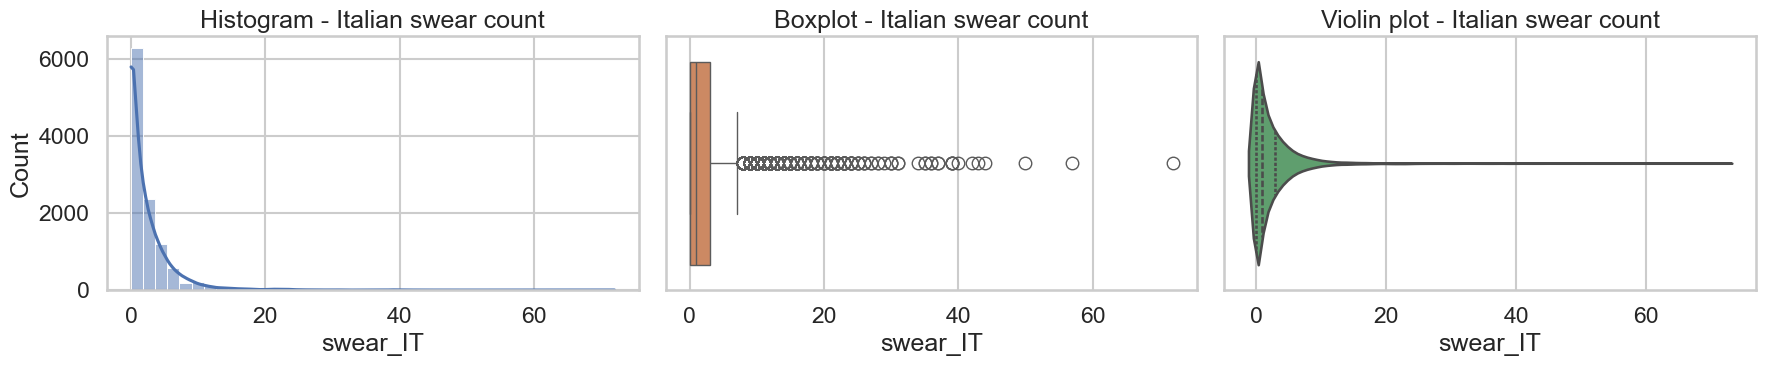

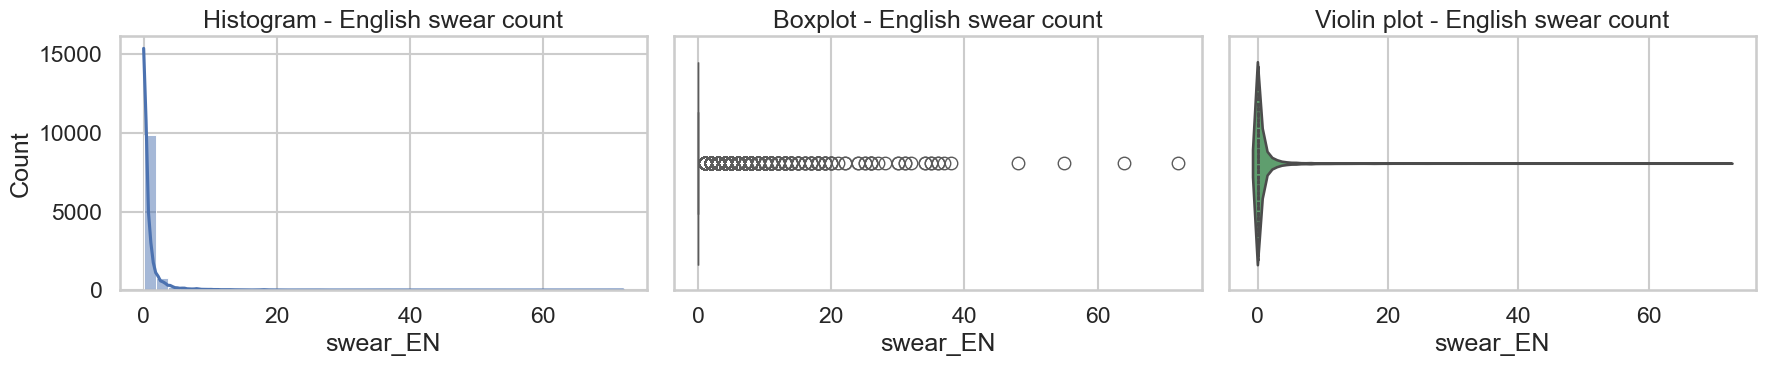

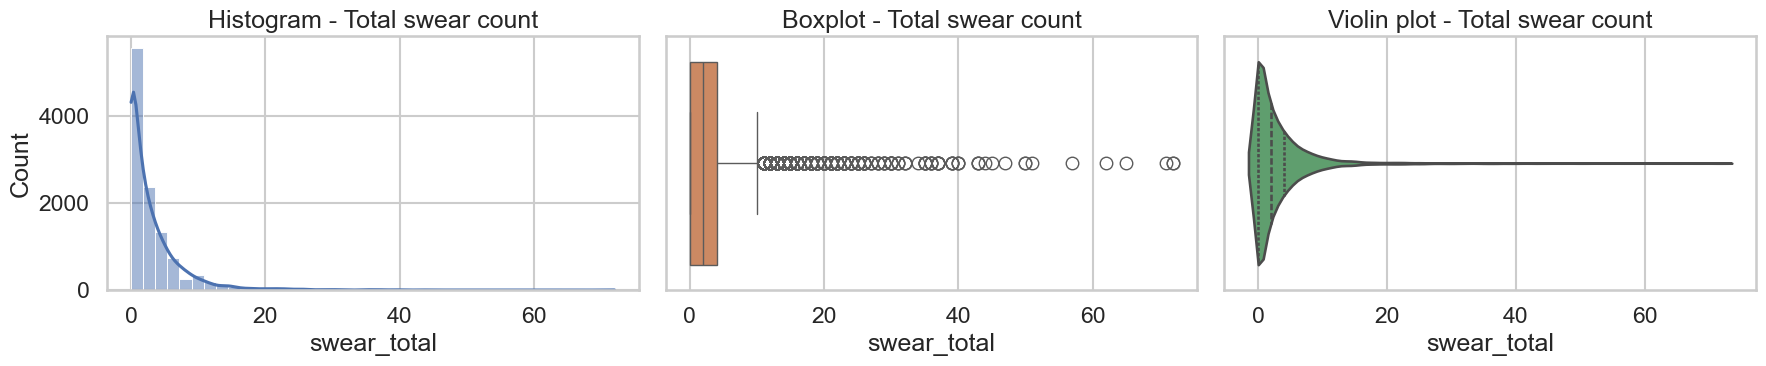

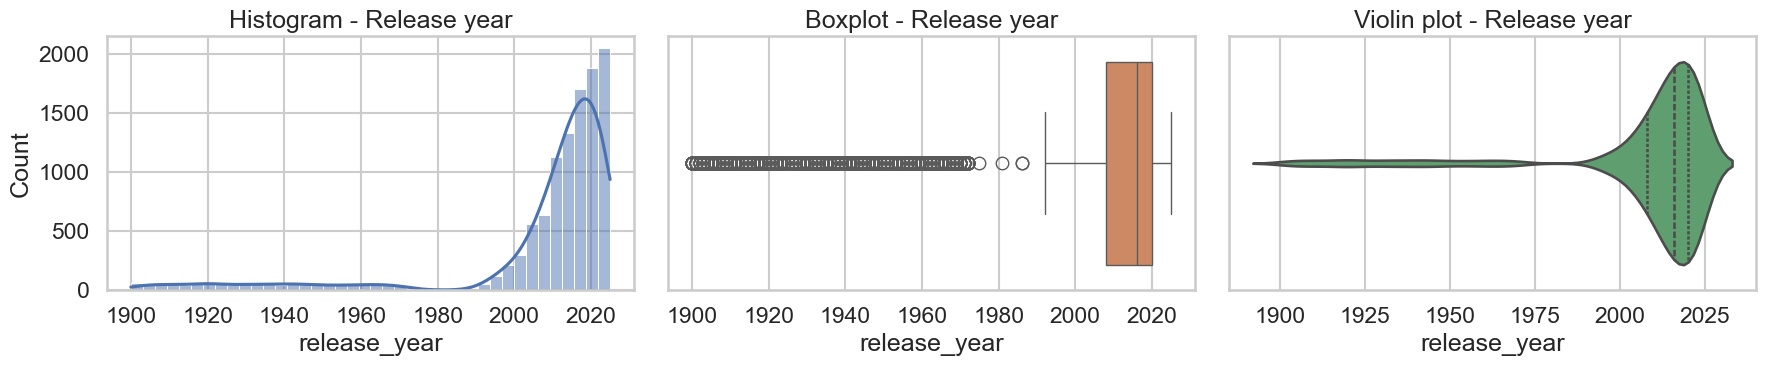

In [70]:
def plot_distribution_triplet(data, column, pretty_name=None, log1p=False):
    series = data[column].dropna()
    if series.empty:
        print(f"Skipping {column}: no valid values.")
        return

    label = pretty_name or column
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(series, bins=40, kde=True, ax=axes[0], color="#4c72b0")
    axes[0].set_title(f"Histogram - {label}")

    sns.boxplot(x=series, ax=axes[1], color="#dd8452")
    axes[1].set_title(f"Boxplot - {label}")

    sns.violinplot(x=series, ax=axes[2], color="#55a868", inner="quartile")
    axes[2].set_title(f"Violin plot - {label}")

    plt.tight_layout()
    plt.show()

    if log1p:
        non_negative = series[series >= 0]
        if not non_negative.empty:
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.histplot(np.log1p(non_negative), bins=40, kde=True, ax=ax, color="#8172b3")
            ax.set_title(f"Log1p histogram - {label}")
            ax.set_xlabel(f"log1p({label})")
            plt.tight_layout()
            plt.show()

variables_to_plot = [
    ("popularity", "Popularity", True),
    ("stats_pageviews", "Pageviews", True),
    ("bpm", "BPM", False),
    ("duration_ms", "Duration (ms)", True),
    ("lexical_density", "Lexical density", False),
    ("swear_IT", "Italian swear count", False),
    ("swear_EN", "English swear count", False),
    ("swear_total", "Total swear count", False),
    ("release_year", "Release year", False),
]

for column, label, use_log in variables_to_plot:
    plot_distribution_triplet(df, column, pretty_name=label, log1p=use_log)


## Swear Density And Regionality

This section connects the custom feature engineering to the project question by comparing profanity density across artist macro-areas and analysing how the geographic origin deviates from the most common origin (north).


,count,mean,median,std
artist_macroarea,,,,
North,4293,0.006735,0.003831,0.009696
Center,1233,0.006654,0.004310,0.008918
South,1715,0.004206,0.001848,0.007042
Islands,707,0.006407,0.004464,0.007404
Missing,3142,0.005681,0.002821,0.009767


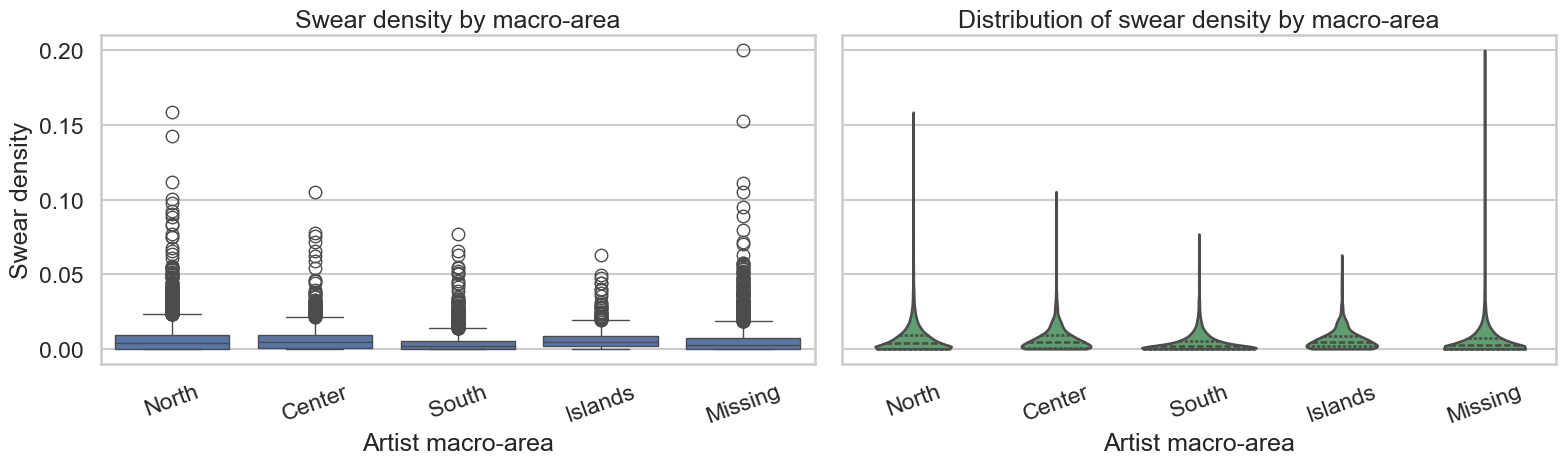

,song_count
artist_macroarea,
North,4368
Center,1233
South,1715
Islands,708
Missing,3142


,count,mean,median,max
artist_macroarea,,,,
North,40,0.314583,0.000000,0.958333
Center,10,0.725000,0.666667,0.958333
South,13,0.663462,0.583333,0.958333
Islands,5,0.858333,0.833333,0.958333
Missing,0,NaN,NaN,NaN


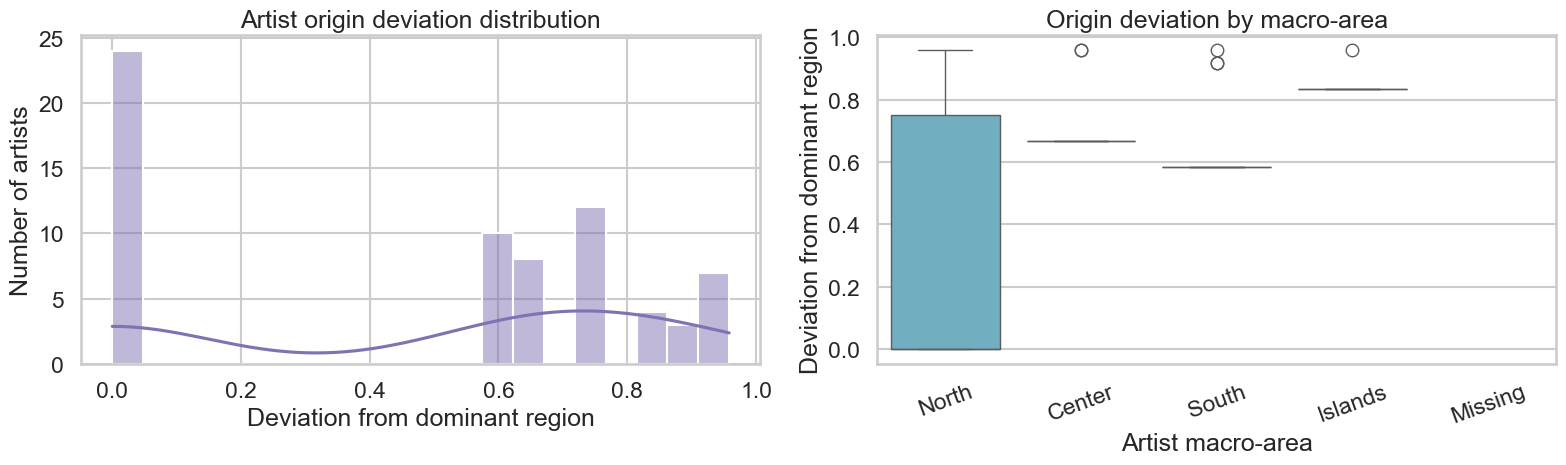

Interpretation note: higher values indicate artists coming from less represented origins, while 0 indicates the dominant origin group.


In [75]:
macroarea_order = ["North", "Center", "South", "Islands", "Missing"]
macroarea_stats = (
    df.groupby("artist_macroarea")["swear_density_total"]
    .agg(["count", "mean", "median", "std"])
    .reindex(macroarea_order)
)

display(macroarea_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
sns.boxplot(
    data=df,
    x="artist_macroarea",
    y="swear_density_total",
    order=macroarea_order,
    ax=axes[0],
    color="#4c72b0",
)
axes[0].set_title("Swear density by macro-area")
axes[0].set_xlabel("Artist macro-area")
axes[0].set_ylabel("Swear density")
axes[0].tick_params(axis="x", rotation=20)

sns.violinplot(
    data=df,
    x="artist_macroarea",
    y="swear_density_total",
    order=macroarea_order,
    ax=axes[1],
    color="#55a868",
    inner="quartile",
    cut=0,
)
axes[1].set_title("Distribution of swear density by macro-area")
axes[1].set_xlabel("Artist macro-area")
axes[1].set_ylabel("Swear density")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

coverage_by_macroarea = df["artist_macroarea"].value_counts().reindex(macroarea_order)
display(coverage_by_macroarea.rename("song_count").to_frame())

# Geographic deviation representation (artist-level)
artist_geo = (
    df[["id_author", "artist_macroarea", "artist_geographic_diversity"]]
    .drop_duplicates(subset=["id_author"])
)

geo_deviation_summary = (
    artist_geo.groupby("artist_macroarea")["artist_geographic_diversity"]
    .agg(["count", "mean", "median", "max"])
    .reindex(macroarea_order)
)
display(geo_deviation_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(
    artist_geo["artist_geographic_diversity"].dropna(),
    bins=20,
    kde=True,
    ax=axes[0],
    color="#8172b3",
)
axes[0].set_title("Artist origin deviation distribution")
axes[0].set_xlabel("Deviation from dominant region")
axes[0].set_ylabel("Number of artists")

sns.boxplot(
    data=artist_geo,
    x="artist_macroarea",
    y="artist_geographic_diversity",
    order=macroarea_order,
    ax=axes[1],
    color="#64b5cd",
)
axes[1].set_title("Origin deviation by macro-area")
axes[1].set_xlabel("Artist macro-area")
axes[1].set_ylabel("Deviation from dominant region")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print(
    "Interpretation note: higher values indicate artists coming from less represented origins, "
    "while 0 indicates the dominant origin group."
)


# Audio Signature
This section analyse the audio features of the songs correlating to geographic an swear data. We introduce a categorical feature that can be more intuitive than many numerical ones for a more understandable cross-correlation of the data.

,song_count
audio_style,
aggressive,296
energetic,1299
bright,459
mellow,1615
balanced,7433
unknown,64


,song_count,mean_swear_total,mean_swear_density,median_geo_deviation,mean_geo_deviation
audio_style,,,,,
aggressive,296,5.091216,0.008783,0.666667,0.563502
energetic,1299,3.424172,0.006483,0.666667,0.488350
bright,459,3.422658,0.006013,0.666667,0.481481
mellow,1615,2.876780,0.005766,0.583333,0.432550
balanced,7433,2.934347,0.005893,0.666667,0.502327
unknown,64,1.875000,0.004161,0.000000,0.314394


audio_style,aggressive,energetic,bright,mellow,balanced,unknown
artist_macroarea,,,,,,
North,0.008272,0.006622,0.006795,0.008246,0.006428,0.003863
Center,0.009609,0.006989,0.009341,0.005785,0.006499,0.008210
South,0.010227,0.005375,0.004343,0.003659,0.004034,0.002863
Islands,0.006750,0.005990,0.004873,0.005255,0.006721,0.000000
Missing,0.009589,0.006812,0.005259,0.004261,0.005750,0.004107


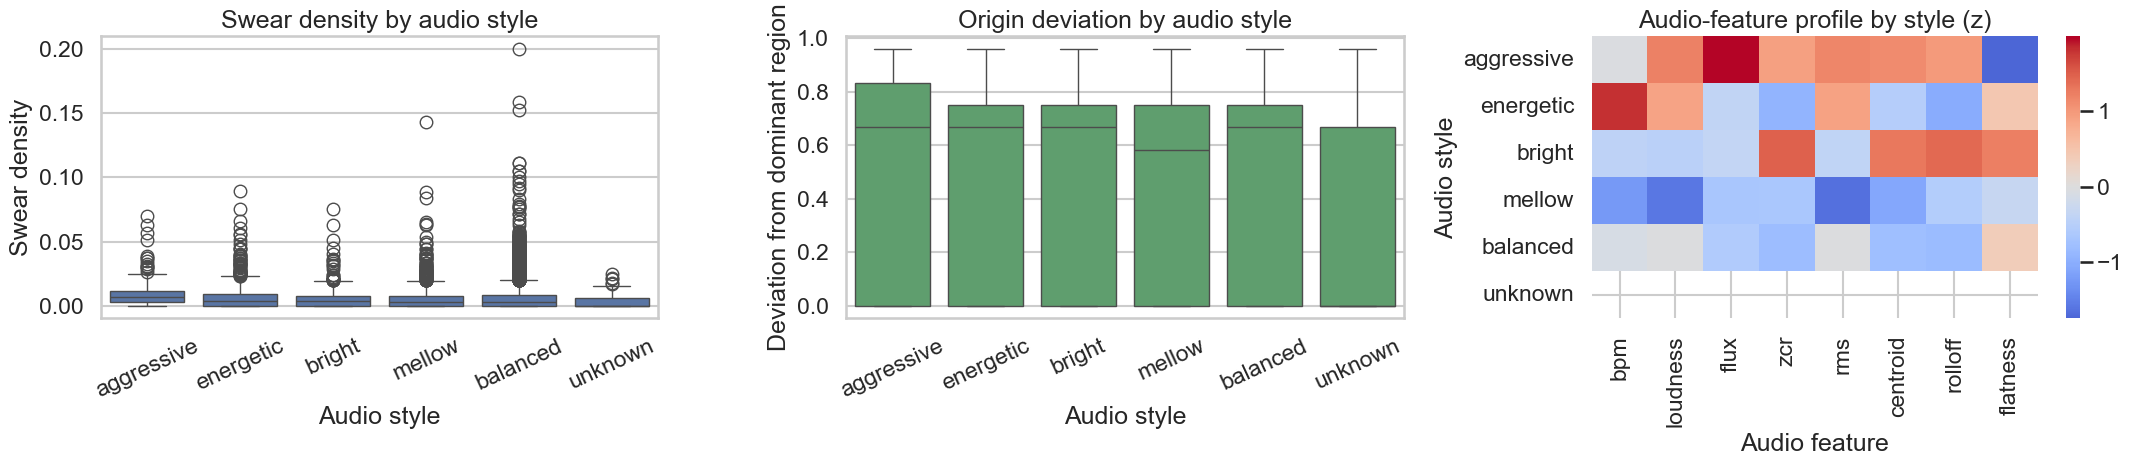

Interpretation note: these style labels are rule-based proxies from audio descriptors; they are useful for segmentation and comparison, not as ground-truth music genres.


In [77]:
# Audio style labeling + comparison with swear presence and geographic origin

analysis_cols = [
    "bpm",
    "loudness",
    "flux",
    "zcr",
    "rms",
    "centroid",
    "rolloff",
    "flatness",
    "swear_total",
    "swear_density_total",
    "artist_macroarea",
    "artist_geographic_diversity",
]
audio_df = df[analysis_cols].copy()

# Row-wise z-scores for selected audio descriptors
zscore_cols = ["bpm", "loudness", "flux", "zcr", "rms", "centroid", "rolloff", "flatness"]
for col in zscore_cols:
    audio_df[f"z_{col}"] = uf.zscore_series(audio_df[col])

def infer_audio_style(row):
    # Rule-based style proxy: transparent and easy to explain in report.
    loud = row["z_loudness"]
    flux = row["z_flux"]
    zcr = row["z_zcr"]
    bpm = row["z_bpm"]
    rms = row["z_rms"]
    cent = row["z_centroid"]
    roll = row["z_rolloff"]
    flat = row["z_flatness"]

    if pd.notna(loud) and pd.notna(flux) and pd.notna(zcr) and (loud > 0.6 and flux > 0.6 and zcr > 0.3):
        return "aggressive"
    if pd.notna(bpm) and pd.notna(rms) and (bpm > 0.7 and rms > 0.2):
        return "energetic"
    if pd.notna(cent) and pd.notna(roll) and pd.notna(flat) and (cent > 0.6 and roll > 0.6 and flat > 0):
        return "bright"
    if pd.notna(loud) and pd.notna(bpm) and (loud < -0.5 and bpm < -0.3):
        return "mellow"
    if row[[f"z_{c}" for c in ["bpm", "loudness", "flux", "zcr", "rms", "centroid", "rolloff", "flatness"]]].notna().sum() < 4:
        return "unknown"
    return "balanced"

audio_df["audio_style"] = audio_df.apply(infer_audio_style, axis=1)
df["audio_style"] = audio_df["audio_style"]

style_order = ["aggressive", "energetic", "bright", "mellow", "balanced", "unknown"]
style_counts = audio_df["audio_style"].value_counts().reindex(style_order).fillna(0).astype(int)
display(style_counts.rename("song_count").to_frame())

style_profile = (
    audio_df.groupby("audio_style")
    .agg(
        song_count=("audio_style", "size"),
        mean_swear_total=("swear_total", "mean"),
        mean_swear_density=("swear_density_total", "mean"),
        median_geo_deviation=("artist_geographic_diversity", "median"),
        mean_geo_deviation=("artist_geographic_diversity", "mean"),
    )
    .reindex(style_order)
)
display(style_profile)

# Macro-area x style table: mean swear density
audio_geo_table = (
    audio_df.pivot_table(
        index="artist_macroarea",
        columns="audio_style",
        values="swear_density_total",
        aggfunc="mean",
    )
    .reindex(["North", "Center", "South", "Islands", "Missing"])
    .reindex(columns=style_order)
)
display(audio_geo_table)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# 1) Swear density by inferred audio style
sns.boxplot(
    data=audio_df,
    x="audio_style",
    y="swear_density_total",
    order=style_order,
    ax=axes[0],
    color="#4c72b0",
)
axes[0].set_title("Swear density by audio style")
axes[0].set_xlabel("Audio style")
axes[0].set_ylabel("Swear density")
axes[0].tick_params(axis="x", rotation=25)

# 2) Geographic deviation by inferred audio style
sns.boxplot(
    data=audio_df,
    x="audio_style",
    y="artist_geographic_diversity",
    order=style_order,
    ax=axes[1],
    color="#55a868",
)
axes[1].set_title("Origin deviation by audio style")
axes[1].set_xlabel("Audio style")
axes[1].set_ylabel("Deviation from dominant region")
axes[1].tick_params(axis="x", rotation=25)

# 3) Heatmap of audio signatures by style
style_audio_means = (
    audio_df.groupby("audio_style")[["bpm", "loudness", "flux", "zcr", "rms", "centroid", "rolloff", "flatness"]]
    .mean()
    .reindex(style_order)
)
style_audio_means_z = style_audio_means.apply(lambda s: (s - s.mean()) / s.std(ddof=0), axis=0)
sns.heatmap(style_audio_means_z, cmap="coolwarm", center=0, ax=axes[2])
axes[2].set_title("Audio-feature profile by style (z)")
axes[2].set_xlabel("Audio feature")
axes[2].set_ylabel("Audio style")

plt.tight_layout()
plt.show()

print(
    "Interpretation note: these style labels are rule-based proxies from audio descriptors; "
    "they are useful for segmentation and comparison, not as ground-truth music genres."
)


,song_count
mood_label,
energetic,1052
cheerful,2133
calm,988
sad,1714
tense,1358
aggressive,774
neutral,3147


,song_count,mean_swear_total,mean_swear_density,median_geo_deviation,mean_geo_deviation
mood_label,,,,,
energetic,1052,4.519962,0.008338,0.666667,0.487821
cheerful,2133,3.488045,0.006898,0.666667,0.501843
calm,988,3.047571,0.006160,0.666667,0.485992
sad,1714,1.875729,0.004201,0.583333,0.473925
tense,1358,3.295287,0.006007,0.666667,0.491481
aggressive,774,2.763566,0.005498,0.583333,0.453547
neutral,3147,2.881474,0.005716,0.666667,0.505408


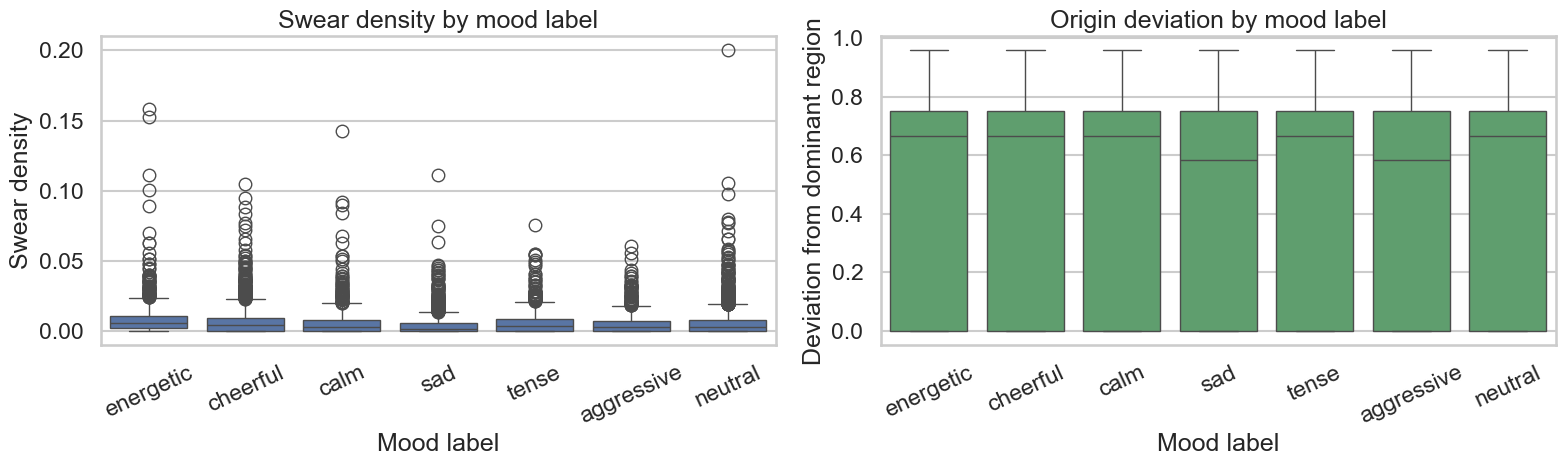

Interpretation note: Mood labels are based on a weighted combination of normalized audio features, following academic MER practice. Valence is less reliable than arousal with low-level features only.


In [78]:
# Valence–Arousal Mood Labeling (MER-inspired)
# Academic mapping of audio features to 2D mood space with quantile-based thresholds

# 1. Normalize features to [0,1] (min-max)
def minmax_norm(series):
    numeric = pd.to_numeric(series, errors="coerce")
    return (numeric - numeric.min()) / (numeric.max() - numeric.min())

# Features for arousal and valence
arousal_features = ["bpm", "loudness", "rms", "flux", "spectral_complexity"]
valence_features = ["centroid", "rolloff", "pitch", "flatness", "zcr"]

# Normalize all needed features
for col in arousal_features + valence_features:
    df[f"norm_{col}"] = minmax_norm(df[col])

# 2. Compute arousal and valence scores (weighted sum, as per academic guidance)
df["arousal_score"] = (
    0.30 * df["norm_bpm"] +
    0.25 * df["norm_loudness"] +
    0.20 * df["norm_rms"] +
    0.15 * df["norm_flux"] +
    0.10 * df["norm_spectral_complexity"]
)
df["valence_score"] = (
    0.30 * df["norm_centroid"] +
    0.20 * df["norm_rolloff"] +
    0.20 * df["norm_pitch"] +
    0.15 * (1 - df["norm_flatness"]) +
    0.15 * (1 - df["norm_zcr"])
)

# 3. Normalize arousal/valence scores to [0,1] for quantile thresholding
def norm01(series):
    return (series - series.min()) / (series.max() - series.min())
df["arousal_score_n"] = norm01(df["arousal_score"])
df["valence_score_n"] = norm01(df["valence_score"])

# 4. Quantile thresholds (tertiles)
a_hi = df["arousal_score_n"] > df["arousal_score_n"].quantile(0.66)
a_lo = df["arousal_score_n"] < df["arousal_score_n"].quantile(0.33)
v_hi = df["valence_score_n"] > df["valence_score_n"].quantile(0.66)
v_lo = df["valence_score_n"] < df["valence_score_n"].quantile(0.33)

# 5. Assign mood category (6-class system)
def assign_mood(row):
    a = row["arousal_score_n"]
    v = row["valence_score_n"]
    a_hi = a > df["arousal_score_n"].quantile(0.66)
    a_lo = a < df["arousal_score_n"].quantile(0.33)
    v_hi = v > df["valence_score_n"].quantile(0.66)
    v_lo = v < df["valence_score_n"].quantile(0.33)
    if v_hi and a > df["arousal_score_n"].quantile(0.80):
        return "energetic"
    if v_hi and not a_hi:
        return "cheerful"
    if v_lo and a_lo:
        return "sad"
    if v_lo and a_hi:
        return "aggressive"
    if not v_hi and a_hi:
        return "tense"
    if not v_lo and a_lo:
        return "calm"
    return "neutral"
df["mood_label"] = df.apply(assign_mood, axis=1)

# Summary table: mood label counts and mean audio features
mood_order = ["energetic", "cheerful", "calm", "sad", "tense", "aggressive", "neutral"]
mood_counts = df["mood_label"].value_counts().reindex(mood_order).fillna(0).astype(int)
display(mood_counts.rename("song_count").to_frame())

mood_profile = (
    df.groupby("mood_label")
    .agg(
        song_count=("mood_label", "size"),
        mean_swear_total=("swear_total", "mean"),
        mean_swear_density=("swear_density_total", "mean"),
        median_geo_deviation=("artist_geographic_diversity", "median"),
        mean_geo_deviation=("artist_geographic_diversity", "mean"),
    )
    .reindex(mood_order)
)
display(mood_profile)

# Visualization: boxplots for swear density and geo deviation by mood
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(
    data=df,
    x="mood_label",
    y="swear_density_total",
    order=mood_order,
    ax=axes[0],
    color="#4c72b0",
)
axes[0].set_title("Swear density by mood label")
axes[0].set_xlabel("Mood label")
axes[0].set_ylabel("Swear density")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(
    data=df,
    x="mood_label",
    y="artist_geographic_diversity",
    order=mood_order,
    ax=axes[1],
    color="#55a868",
)
axes[1].set_title("Origin deviation by mood label")
axes[1].set_xlabel("Mood label")
axes[1].set_ylabel("Deviation from dominant region")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

print(
    "Interpretation note: Mood labels are based on a weighted combination of normalized audio features, following academic MER practice. Valence is less reliable than arousal with low-level features only."
)


## Correlation And Redundancy Analysis

We restrict the correlation matrices to cleaned numeric variables, compare Pearson and Spearman correlation, and highlight strongly related pairs.


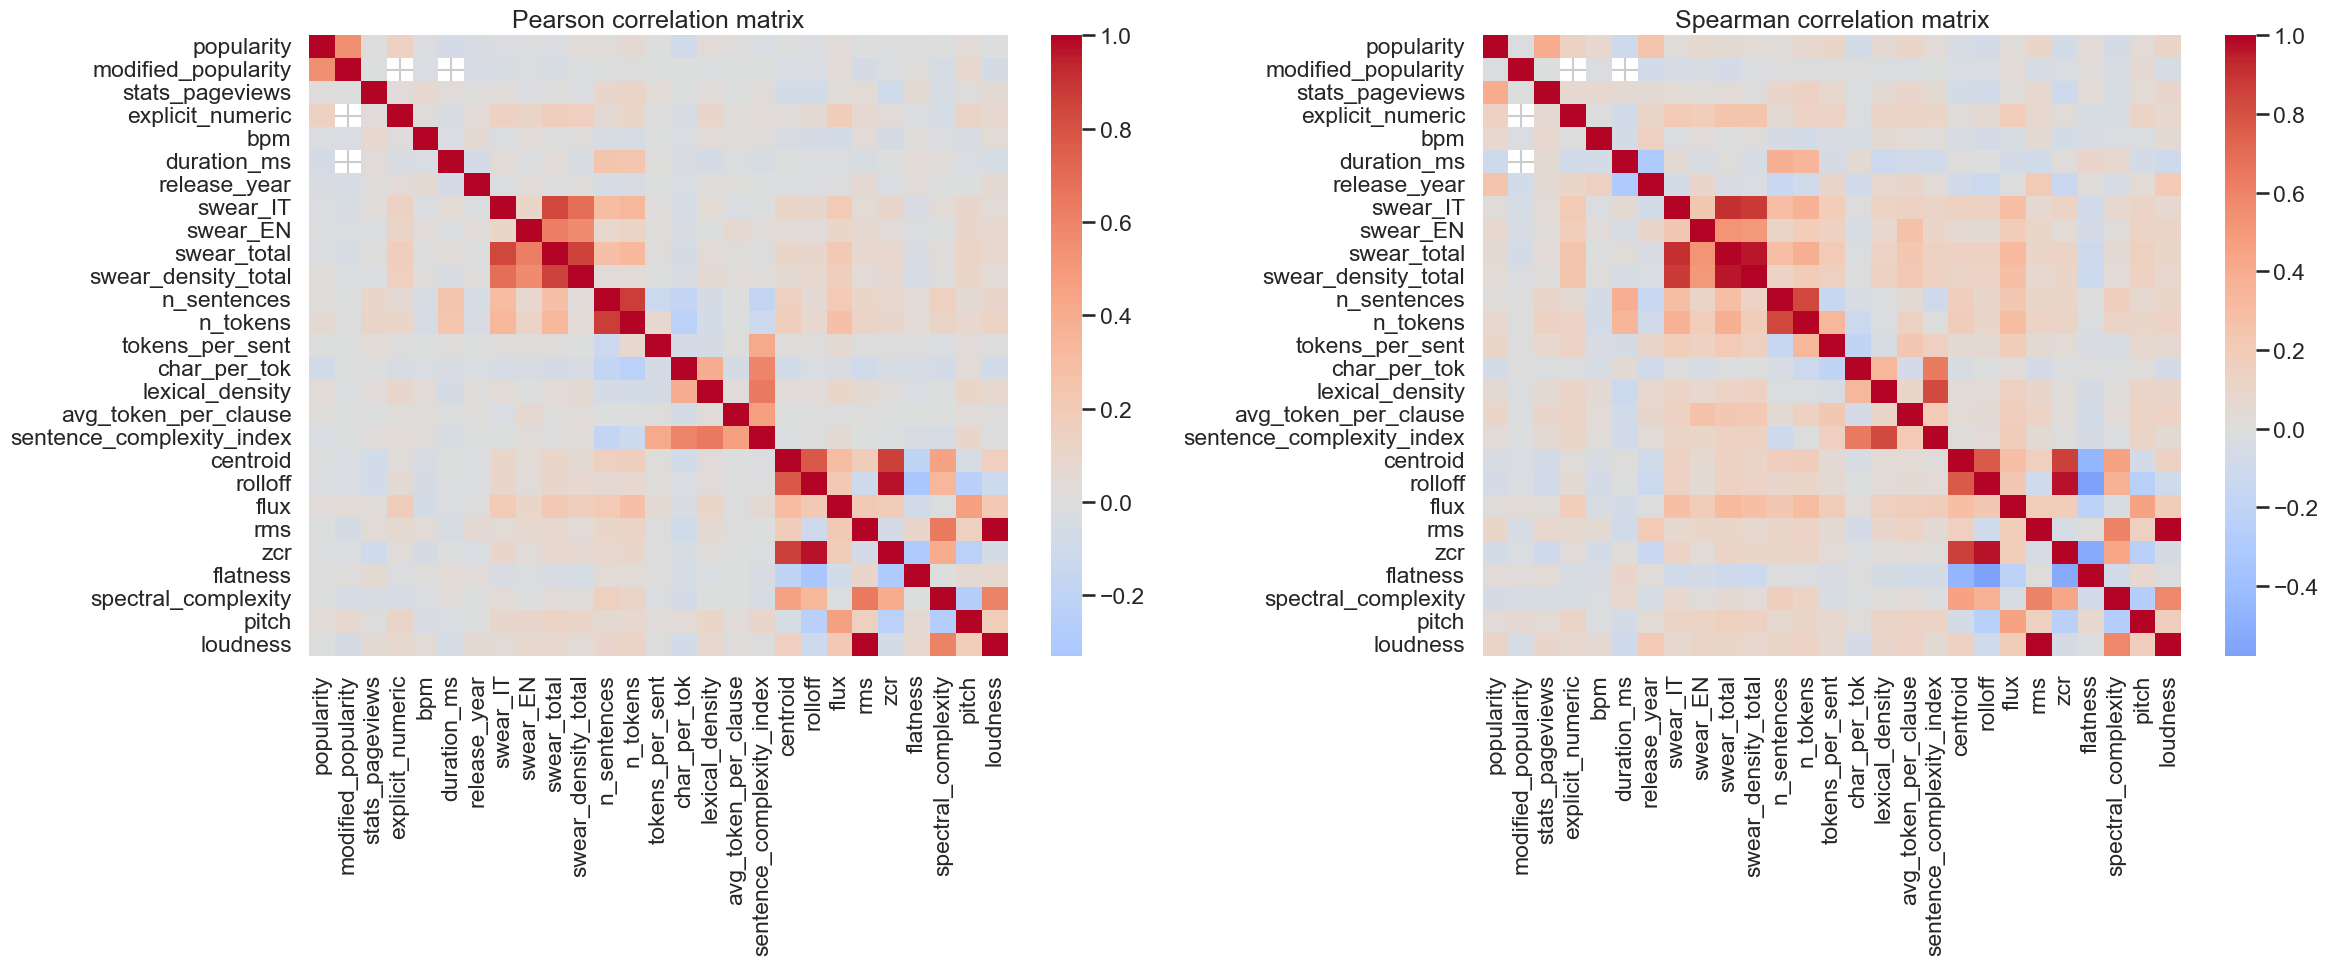

,feature_a,feature_b,correlation
593,rms,loudness,0.995555
535,rolloff,zcr,0.969101
309,n_sentences,n_tokens,0.867722
508,centroid,zcr,0.864465
253,swear_total,swear_density_total,0.850815
198,swear_IT,swear_total,0.842240
505,centroid,rolloff,0.775666


,popularity,stats_pageviews,explicit_numeric,swear_density_total,sentence_complexity_index,bpm,duration_ms,release_year
avg_token_per_clause,0.009127,-0.004244,0.017821,0.030421,0.465024,0.022503,-0.011927,0.009068
bpm,-0.016027,0.073400,0.010930,0.011372,0.012451,1.000000,-0.024087,0.057980
centroid,-0.005341,-0.076413,0.022023,0.064252,-0.021909,-0.034110,0.000728,-0.018405
char_per_tok,-0.091025,-0.004183,-0.031418,-0.038724,0.597111,-0.028625,-0.032533,-0.026621
duration_ms,-0.064938,0.031006,-0.035152,-0.037023,-0.043179,-0.024087,1.000000,-0.068144
explicit_numeric,0.140699,0.028444,1.000000,0.162586,0.038477,0.010930,-0.035152,0.038115
flatness,0.004669,0.051428,-0.021993,-0.054065,-0.032699,0.008762,0.037301,0.025773
flux,0.029226,0.019972,0.175525,0.166526,0.061990,-0.071779,-0.021428,0.005789
lexical_density,0.034742,0.027684,0.090914,0.062765,0.645220,0.035096,-0.057187,0.008615
loudness,-0.003603,0.050282,0.079475,0.048064,0.002904,0.041160,-0.047308,0.064468


In [76]:
correlation_columns = [
    "popularity",
    "modified_popularity",
    "stats_pageviews",
    "explicit_numeric",
    "bpm",
    "duration_ms",
    "release_year",
    "swear_IT",
    "swear_EN",
    "swear_total",
    "swear_density_total",
    "n_sentences",
    "n_tokens",
    "tokens_per_sent",
    "char_per_tok",
    "lexical_density",
    "avg_token_per_clause",
    "sentence_complexity_index",
    "centroid",
    "rolloff",
    "flux",
    "rms",
    "zcr",
    "flatness",
    "spectral_complexity",
    "pitch",
    "loudness",
]

corr_df = df[correlation_columns].copy()
pearson_corr = corr_df.corr(method="pearson")
spearman_corr = corr_df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
sns.heatmap(pearson_corr, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson correlation matrix")

sns.heatmap(spearman_corr, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman correlation matrix")

plt.tight_layout()
plt.show()

def top_correlation_pairs(corr_matrix, threshold=0.7):
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    return pairs.loc[pairs["correlation"].abs() >= threshold].sort_values(
        "correlation",
        key=lambda s: s.abs(),
        ascending=False,
    )

high_corr_pairs = top_correlation_pairs(pearson_corr, threshold=0.7)
focus_features = [
    "popularity",
    "stats_pageviews",
    "explicit_numeric",
    "swear_density_total",
    "sentence_complexity_index",
    "bpm",
    "duration_ms",
    "release_year",
]

focus_corr = pearson_corr.loc[focus_features, corr_df.columns].T.sort_index()

display(high_corr_pairs)
display(focus_corr)


## Discussion Notes For The Report

When writing the final report, discuss both descriptive findings and data limitations:

- `album` / `album_name` and `title` / `full_title` are redundancy candidates, but the richer text version was retained.
- Geography is informative but incomplete, so regional findings must be framed cautiously.
- Popularity and pageviews are likely skewed and should be interpreted with outlier awareness.
- Swear density is more comparable than raw swear counts because it adjusts for lyric length.
- The sentence complexity index is intentionally transparent: higher values mean longer, denser, and lexically richer sentences.
- The new engineered features (audio signature, artist consistency, engagement ratio, geographic diversity, etc.) provide interpretable axes for clustering and analysis, but their reliability depends on the underlying data quality.
- The categorical `audio_style` feature is a rule-based proxy for segmentation and comparison, not a ground-truth genre label.
- The valence–arousal mood label system is based on a weighted combination of normalized audio features, following academic Music Emotion Recognition (MER) practice. Arousal (energy) is more reliably captured by low-level features than valence (positivity), which is limited by the absence of harmony/lyrics/chroma data.
- Mood labels (energetic, cheerful, calm, sad, tense, aggressive, neutral) are assigned using quantile-based thresholds in the 2D valence–arousal space, providing an interpretable and literature-aligned segmentation for downstream analysis.
- All engineered features and mood labels should be interpreted as proxies: they are useful for clustering, visualization, and exploratory analysis, but not as definitive psychological or genre ground-truths.
